## 패키지 설치

**주의:** 이 셀을 실행한 뒤 반드시 아래 '런타임 재시작' 셀까지 실행하세요.
`mediapipe` / `opencv-python-headless`가 Colab 기본 numpy와 다른 버전을 설치하면서
`ValueError: numpy.dtype size changed` 오류가 나기 때문입니다 (numpy 재설치 후 재시작 필요).

In [2]:
%%capture
!pip install -q diffusers transformers peft accelerate simple-lama-inpainting mediapipe opencv-python-headless safetensors
!pip install -q -U "torchao>=0.16.0"
# torch / torchvision은 Colab 기본 환경에 이미 설치되어 있습니다 (CUDA 지원 버전).
# 만약 버전 충돌이 나면 아래 주석을 해제해서 재설치하세요.
# !pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu121


런타임 재시작 셀 (세션이 다운되어도 정상동작 당황말고 다음 셀실행)

In [ ]:
import os
os.kill(os.getpid(), 9)   # 또는
# import IPython; IPython.Application.instance().kernel.do_shutdown(True)

## Google Drive 마운트 & 경로 설정

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os

# TODO: 실제 프로젝트 폴더 경로로 수정하세요
ROOT_PATH = "/content/drive/MyDrive/eyebrows"

assert os.path.isdir(ROOT_PATH), f"경로를 찾을 수 없습니다: {ROOT_PATH}"
print("ROOT_PATH:", ROOT_PATH)
print(os.listdir(ROOT_PATH))

# ------------------------------------------------------------------
# [NEW] 테스트할 사진 파일명. 다른 사진으로 테스트하고 싶으면 이 줄만 바꾸면 됩니다.
# 사진은 미리 Google Drive의 ROOT_PATH 폴더( eyebrows/ ) 안에 올려두세요.
# ------------------------------------------------------------------
TEST_IMAGE_NAME = "test.jpg"
TEST_IMAGE_PATH = os.path.join(ROOT_PATH, TEST_IMAGE_NAME)
assert os.path.isfile(TEST_IMAGE_PATH), f"사진을 찾을 수 없습니다: {TEST_IMAGE_PATH}"
print("TEST_IMAGE_PATH:", TEST_IMAGE_PATH)


ROOT_PATH: /content/drive/MyDrive/eyebrows
['util', 'masking_bisenet', 'lora_checkpoint', 'data', 'output_img', 'pipeline', 'test.jpg', 'eyebrow_pipeline_colab (1).ipynb', 'backbone.ipynb', 'result_20260817_041518.png', 'eyebrow_pipeline_colab_phase1.ipynb', 'test2.jpg', 'eyebrow_pipeline_colab_phase2.ipynb', 'CelebFit.ipynb', 'bisnet+mediapipe.ipynb', 'eyebrow_pipeline_colab_phase2_1.ipynb']
TEST_IMAGE_PATH: /content/drive/MyDrive/eyebrows/test.jpg


## 다양한 툴 Import & 초기 설정

In [5]:
import sys
import datetime
import torch
import cv2
import numpy as np
from PIL import Image

sys.path.insert(0, ROOT_PATH)

from masking_bisenet.generate_mask_bisenet import generate_bisenet_face_parts_mask  # [Phase2] 드라이브에 있는 BiSeNet 코드
#from util.crop_face import get_zoom_crop_info, apply_crop, restore_crop
# Colab CUDA 환경: onnxruntime-gpu 충돌 방지용 (SD는 PyTorch만 사용)
try:
    import diffusers.utils.import_utils as _diffusers_import_utils
    _diffusers_import_utils._onnx_available = False
except ImportError:
    pass

from diffusers import StableDiffusionInpaintPipeline, UniPCMultistepScheduler, UNet2DConditionModel, AutoencoderKL
from transformers import CLIPTextModel
from simple_lama_inpainting import SimpleLama
from peft import PeftModel
import transformers
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

if not hasattr(transformers, 'CLIPFeatureExtractor'):
    transformers.CLIPFeatureExtractor = transformers.CLIPImageProcessor

root_path = ROOT_PATH  # 기존 코드와 변수명 호환


Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


## 4. MediaPipe FaceLandmarker 모델 다운로드

In [6]:
model_path = os.path.join(root_path, "data", "face_landmarker.task")
if not os.path.exists(model_path):
    print("Downloading face_landmarker.task...")
    import urllib.request
    os.makedirs(os.path.dirname(model_path), exist_ok=True)
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task',
        model_path
    )
    print("face_landmarker.task download complete.")

_detector = None

# 미디어 파잎에서 우리가 원하는 위치의 좌표를 detect
def _get_detector():
    global _detector
    if _detector is None:
        options = vision.FaceLandmarkerOptions(
            base_options=python.BaseOptions(
                model_asset_path=model_path,
                delegate=python.BaseOptions.Delegate.CPU,
            ),
            num_faces=1,
        )
        _detector = vision.FaceLandmarker.create_from_options(options)
    return _detector

# MEDIA PIPE 에서 추출한 얼굴 각 위치의 정점
LEFT_BROW  = [156, 70, 63, 105, 66, 107, 221, 222, 223, 224, 225, 113, 124]
RIGHT_BROW = [383, 300, 293, 334, 296, 336, 441, 442, 443, 444, 445, 342, 353]

## 눈 위치 모음 (마스킹 시 눈썹 바운더리와 겹치는 눈 위치는 제외하기 위해)
LEFT_EYE   = [33, 7, 163, 144, 145, 153, 154, 155, 133, 173, 157, 158, 159, 160, 161, 246]
RIGHT_EYE  = [362, 382, 381, 380, 374, 373, 390, 249, 263, 466, 388, 387, 386, 385, 384, 398]


## [Phase 1] 마스크 안전장치 추가

기존 문제:
- `dilate_px`, `eye_guard_px`가 고정 픽셀값(23)이라 사람마다 얼굴 크기가 달라지면 잘 안 맞음
  → 어떤 사람은 잔털이 남고, 어떤 사람은 눈 쪽까지 마스크가 침범
- 랜드마크 다각형은 눈썹 다각형 + 팽창만으로 만들어서, 다각형 밖으로 삐져나온 낱개 잔털을 못 잡음

이번에 추가한 것:
1. `_adaptive_px()` — 고정 px 대신 **눈 사이 거리(interocular distance)** 에 비례한 px를 자동 계산.
   얼굴이 크게 잡히든 작게 잡히든 항상 같은 "비율"로 보정됨.
2. `detect_stray_hairs()` — black-hat 형태학 필터로 눈썹 마스크 주변의 "가늘고 어두운 선 구조"(잔털)를
   직접 찾아서 마스크에 합침. 피부과 영상에서 병변 위 잔털을 지우는 기법을 응용.
3. 눈 가드(eye_guard)는 그대로 유지하되, 반경도 얼굴 크기에 비례하도록 자동 계산 → 안전장치를 유지하면서
   개인차에 더 잘 맞도록 개선.

`get_brow_mask()`의 시그니처는 그대로라 아래 셀들에서 별도 수정 없이 바로 재사용 가능합니다
(`dilate_px`/`eye_guard_px`를 안 주면 자동 계산, 예전처럼 숫자를 직접 주면 그 값을 그대로 씀).


In [7]:
import cv2
import numpy as np
import mediapipe as mp

# 미디어파잎으로 바로 위에 설정한 좌표들의 색깔을 담아놓은 딕셔너리
REGIONS = {
    "LEFT_BROW":  (LEFT_BROW,  (255,  80,  80)),   # BGR
    "RIGHT_BROW": (RIGHT_BROW, (255,  80,  80)),
    "LEFT_EYE":   (LEFT_EYE,   ( 80, 220, 255)),
    "RIGHT_EYE":  (RIGHT_EYE,  ( 80, 220, 255)),
}

def dilate_mask(mask, pixels=5):
    """마스크의 흰색 영역을 사방으로 `pixels`만큼 부풀린다 (팽창 / dilation)."""
    k = 2 * pixels + 1
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
    return cv2.dilate(mask, kernel, iterations=1)


def get_landmarks(image_bgr):
    """MediaPipe FaceLandmarker로 얼굴 랜드마크 478개의 픽셀 좌표를 추출한다."""
    h, w = image_bgr.shape[:2]
    mp_img = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB),
    )
    res = _get_detector().detect(mp_img)
    if not res.face_landmarks:
        return None
    lm = res.face_landmarks[0]
    return np.array([[p.x * w, p.y * h] for p in lm], dtype=np.int32)


# ------------------------------------------------------------------
# [Phase1] 고정 px 대신 "눈 사이 거리(interocular distance)"에 비례한 px를 쓴다.
# ------------------------------------------------------------------
def _interocular_distance(pts):
    left_center = pts[LEFT_EYE].mean(axis=0)
    right_center = pts[RIGHT_EYE].mean(axis=0)
    return float(np.linalg.norm(left_center - right_center))


def _adaptive_px(pts, ratio, min_px=2, max_px=60):
    """interocular distance에 비례하는 픽셀 반경 계산."""
    dist = _interocular_distance(pts)
    px = int(round(dist * ratio))
    return int(np.clip(px, min_px, max_px))


def get_eye_guard_mask(pts, image_shape, eye_guard_px=None):
    """[Phase1] 눈 보호 마스크만 따로 만드는 헬퍼.
    Phase1(랜드마크)·Phase2(BiSeNet) 마스크가 이 함수를 공유해서 쓰고,
    STEP3 생성 마스크의 feather(블러) 이후 재클램프에도 재사용한다."""
    h, w = image_shape[:2]
    if eye_guard_px is None:
        eye_guard_px = _adaptive_px(pts, ratio=0.07)
    eye_guard = np.zeros((h, w), dtype=np.uint8)
    cv2.fillPoly(eye_guard, [pts[LEFT_EYE], pts[RIGHT_EYE]], 255)
    if eye_guard_px > 0:
        eye_guard = dilate_mask(eye_guard, eye_guard_px)
    return eye_guard


# ------------------------------------------------------------------
# [Phase1] 잔털(stray hair) 검출 — black-hat 형태학 필터.
# ------------------------------------------------------------------
def detect_stray_hairs(image_bgr, brow_mask, search_px=18,
                        blackhat_ksize=9, thresh=12):
    """
    Args:
        image_bgr      : (H, W, 3) uint8 원본/크롭 이미지
        brow_mask      : 눈썹 마스크. 이 주변에서만 잔털을 찾는다.
        search_px      : brow_mask를 얼마나 더 넓혀서 탐색할지(px)
        blackhat_ksize : black-hat 커널 크기.
        thresh         : black-hat 응답 임계값. 낮을수록 더 많이 잡되 노이즈도 늘어난다.
    """
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (blackhat_ksize, blackhat_ksize))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, hair = cv2.threshold(blackhat, thresh, 255, cv2.THRESH_BINARY)

    search_area = dilate_mask(brow_mask, search_px)
    hair[search_area == 0] = 0
    return hair


def get_brow_mask(image_bgr, dilate_px=None, eye_guard_px=None,
                   hair_search_px=18, hair_thresh=12, detect_hair=True):
    """[Phase1] 랜드마크 다각형 + 팽창 + 잔털 검출 + 눈 가드로 만드는 마스크."""
    pts = get_landmarks(image_bgr)
    if pts is None:
        return None

    if dilate_px is None:
        dilate_px = _adaptive_px(pts, ratio=0.045)

    mask = np.zeros(image_bgr.shape[:2], dtype=np.uint8)
    cv2.fillPoly(mask, [pts[LEFT_BROW], pts[RIGHT_BROW]], 255)
    if dilate_px > 0:
        mask = dilate_mask(mask, dilate_px)

    if detect_hair:
        stray = detect_stray_hairs(image_bgr, mask,
                                    search_px=hair_search_px, thresh=hair_thresh)
        mask = cv2.bitwise_or(mask, stray)

    eye_guard = get_eye_guard_mask(pts, image_bgr.shape, eye_guard_px)
    mask[eye_guard > 0] = 0

    return mask


## [Phase 2] 마스크 소스를 BiSeNet 픽셀 분류로 전환

Phase 1까지는 "랜드마크로 그린 다각형"이 마스크의 기본 형태였고, 잔털 검출을 그 위에 덧붙이는 정도였습니다.
Phase 2에서는 실제로 지울 픽셀 자체를 **BiSeNet(얼굴 파싱 모델)의 눈썹 클래스 예측 결과**가 결정하도록 바꿉니다.

- BiSeNet은 픽셀 단위로 "이게 눈썹이다/아니다"를 직접 분류하므로, 사람마다 다른 눈썹 모양을 랜드마크 다각형보다 훨씬 정확하게 따라갑니다.
- MediaPipe 랜드마크는 이제 "대략적인 관심영역(ROI)"으로만 씁니다 — BiSeNet이 눈썹과 무관한 곳(잔머리, 구레나룻 등)을 잘못 눈썹으로 예측했을 때 걸러내는 안전판 역할입니다.
- Phase1의 잔털 검출과 눈 가드는 그대로 유지합니다.
- **BiSeNet 추론이 실패하거나(가중치 파일 없음 등) 결과가 비어 있으면 자동으로 Phase1(랜드마크) 방식으로 폴백합니다.** 두 방식 다 실패하면 크롭 단계에서 만든 기본 마스크까지 3단 폴백됩니다.


In [8]:
import sys, os
sys.path.insert(0, ROOT_PATH)
from masking_bisenet.generate_mask_bisenet import generate_bisenet_face_parts_mask


def get_brow_mask_bisenet(image_bgr, pts=None, roi_pad_ratio=1.6,
                           eye_guard_px=None, hair_search_px=18, hair_thresh=12,
                           detect_hair=True):
    """[Phase2] BiSeNet 눈썹 클래스 예측 + MediaPipe ROI 안전판 + 잔털 검출 + 눈 가드.

    Returns:
        (mask, eye_guard) 튜플. 실패 시 (None, None).
    """
    if pts is None:
        pts = get_landmarks(image_bgr)
    if pts is None:
        return None, None

    h, w = image_bgr.shape[:2]

    # 1) BiSeNet으로 눈썹 클래스 픽셀 직접 예측
    try:
        bisenet_mask = generate_bisenet_face_parts_mask(image_bgr, parts=["eyebrows"])
    except Exception as e:
        print(f"[warn] BiSeNet 추론 실패: {e}")
        return None, None

    if bisenet_mask is None or bisenet_mask.sum() == 0:
        return None, None

    # 2) 랜드마크로 대략적인 눈썹 ROI를 잡아 안전판으로 사용
    #    (BiSeNet이 눈썹과 무관한 부위를 잘못 예측했을 때 걸러낸다)
    brow_pts = np.concatenate([pts[LEFT_BROW], pts[RIGHT_BROW]], axis=0)
    min_x, min_y = brow_pts.min(axis=0)
    max_x, max_y = brow_pts.max(axis=0)
    bw, bh = max_x - min_x, max_y - min_y
    pad_x = int(bw * (roi_pad_ratio - 1) / 2)
    pad_y = int(bh * (roi_pad_ratio - 1) / 2)
    x1, y1 = max(0, min_x - pad_x), max(0, min_y - pad_y)
    x2, y2 = min(w, max_x + pad_x), min(h, max_y + pad_y)
    roi = np.zeros((h, w), dtype=np.uint8)
    roi[y1:y2, x1:x2] = 255

    mask = cv2.bitwise_and(bisenet_mask, roi)
    if mask.sum() == 0:
        # BiSeNet 예측이 ROI 밖에만 있었다면(랜드마크 오차 등) 원본 BiSeNet 결과를 그대로 사용
        mask = bisenet_mask

    # 3) [Phase1] 잔털 검출 — BiSeNet도 옅은 잔털은 배경으로 분류하는 경향이 있어 그대로 유지
    if detect_hair:
        stray = detect_stray_hairs(image_bgr, mask,
                                    search_px=hair_search_px, thresh=hair_thresh)
        mask = cv2.bitwise_or(mask, stray)

    # 4) 눈 가드 (Phase1과 동일한 헬퍼를 공유해서 기준을 통일한다)
    eye_guard = get_eye_guard_mask(pts, image_bgr.shape, eye_guard_px)
    mask[eye_guard > 0] = 0

    return mask, eye_guard


def get_brow_mask_v2(image_bgr, dilate_px=None, eye_guard_px=None,
                      hair_search_px=18, hair_thresh=12, detect_hair=True,
                      use_bisenet=True):
    """[Phase2] BiSeNet 우선 시도 → 실패하면 Phase1(랜드마크) 방식으로 자동 폴백.

    Returns:
        (mask, eye_guard, source) — source는 "bisenet" 또는 "landmark" 또는 None
    """
    pts = get_landmarks(image_bgr)
    if pts is None:
        return None, None, None

    if use_bisenet:
        mask, eye_guard = get_brow_mask_bisenet(
            image_bgr, pts=pts, eye_guard_px=eye_guard_px,
            hair_search_px=hair_search_px, hair_thresh=hair_thresh,
            detect_hair=detect_hair,
        )
        if mask is not None and mask.sum() > 0:
            return mask, eye_guard, "bisenet"
        print("[warn] BiSeNet 마스크 실패/결과 없음 -> Phase1 랜드마크 마스크로 폴백")

    mask = get_brow_mask(image_bgr, dilate_px=dilate_px, eye_guard_px=eye_guard_px,
                          hair_search_px=hair_search_px, hair_thresh=hair_thresh,
                          detect_hair=detect_hair)
    eye_guard = get_eye_guard_mask(pts, image_bgr.shape, eye_guard_px) if mask is not None else None
    return mask, eye_guard, ("landmark" if mask is not None else None)


## 마스크 생성

In [9]:
from google.colab.patches import cv2_imshow
import numpy as np
import mediapipe as mp

img = cv2.imread(TEST_IMAGE_PATH)   # [NEW] 위 셀에서 정한 테스트 이미지 사용

# dilate_px / eye_guard_px를 안 주면 눈 사이 거리 기준으로 자동 계산됨
mask = get_brow_mask(img)

overlay = img.copy()
overlay[mask > 128] = (0, 0, 255)          # BGR
blended = cv2.addWeighted(img, 0.6, overlay, 0.4, 0)

cv2_imshow(mask)
cv2_imshow(blended)

# [NEW-Phase1] 잔털 검출 결과만 따로 확인하고 싶을 때
pts = get_landmarks(img)
if pts is not None:
    brow_only = np.zeros(img.shape[:2], dtype=np.uint8)
    cv2.fillPoly(brow_only, [pts[LEFT_BROW], pts[RIGHT_BROW]], 255)
    brow_only = dilate_mask(brow_only, _adaptive_px(pts, 0.045))
    stray = detect_stray_hairs(img, brow_only)
    print("--- 잔털 검출 결과 (검출된 픽셀만 흰색) ---")
    cv2_imshow(stray)


Output hidden; open in https://colab.research.google.com to view.

### 이 셀은 일단 실행 하지 마

In [10]:
# def _to_mediapipe_srgb(image_np: np.ndarray) -> np.ndarray:
#     """MediaPipe Image() requires contiguous uint8 RGB (OpenCV paths pass BGR)."""
#     if image_np.dtype != np.uint8:
#         image_np = np.clip(image_np, 0, 255).astype(np.uint8)
#     if image_np.ndim == 3 and image_np.shape[2] == 3:
#         image_np = cv2.cvtColor(image_np, cv2.COLOR_BGR2RGB)
#     return np.ascontiguousarray(image_np)


# def get_landmarks_new(image_np):
#     rgb = _to_mediapipe_srgb(image_np)
#     mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
#     result = _get_detector().detect(mp_image)
#     if not result.face_landmarks:
#         return None
#     return result.face_landmarks[0]


# def get_canny_guide(image_np):
#     img = cv2.Canny(image_np, 100, 200)
#     img = img[:, :, None]
#     img = np.concatenate([img, img, img], axis=2)
#     return Image.fromarray(img)



### 이 셀도 실행하지 말기

In [11]:
# def color_transfer(src, ref, mask):
#     bg_mask = (mask == 0)
#     if not np.any(bg_mask):
#         return src
#     src_lab = cv2.cvtColor(src, cv2.COLOR_BGR2LAB).astype(np.float32)
#     ref_lab = cv2.cvtColor(ref, cv2.COLOR_BGR2LAB).astype(np.float32)
#     for i in range(3):
#         src_channel = src_lab[:, :, i]
#         ref_channel = ref_lab[:, :, i]
#         mean_src, std_src = src_channel[bg_mask].mean(), src_channel[bg_mask].std()
#         mean_ref, std_ref = ref_channel[bg_mask].mean(), ref_channel[bg_mask].std()
#         if std_src > 1e-5:
#             src_lab[:, :, i] = (src_channel - mean_src) * (std_ref / std_src) + mean_ref
#         else:
#             src_lab[:, :, i] = src_channel - mean_src + mean_ref
#     return cv2.cvtColor(np.clip(src_lab, 0, 255).astype(np.uint8), cv2.COLOR_LAB2BGR)

## 6. LoRA 체크포인트 경로 탐색

In [12]:
def resolve_lora_checkpoint_path():
    candidates = [
        "celeb_eyebrows_all_gender_integrated",
        "celeb_eyebrows_all_pro_v4",
    ]
    for name in candidates:
        path = os.path.join(root_path, "lora_checkpoint", name)
        unet_weights = os.path.join(path, "unet", "adapter_model.safetensors")
        if os.path.isfile(unet_weights):
            return path, name
    raise FileNotFoundError(
        "LoRA checkpoint not found. Expected one of "
        + ", ".join(candidates)
        + f" under {os.path.join(root_path, 'lora_checkpoint')}"
    )


## 7. 모델 로딩

In [13]:
def load_models():
    base_model_path = "emilianJR/epiCRealism"
    lora_path, lora_name = resolve_lora_checkpoint_path()

    if torch.cuda.is_available():
        device = "cuda"
        dtype = torch.float16
    elif torch.backends.mps.is_available():
        device = "mps"
        dtype = torch.float32
    else:
        device = "cpu"
        dtype = torch.float32

    print(f"Loading base pipeline and LoRA checkpoint ({lora_name}) on {device}...")

    text_encoder = CLIPTextModel.from_pretrained(base_model_path, subfolder="text_encoder", torch_dtype=dtype)
    vae = AutoencoderKL.from_pretrained(base_model_path, subfolder="vae", torch_dtype=dtype)
    unet = UNet2DConditionModel.from_pretrained(base_model_path, subfolder="unet", torch_dtype=dtype)

    pipe = StableDiffusionInpaintPipeline.from_pretrained(
        base_model_path, text_encoder=text_encoder, vae=vae, unet=unet,
        torch_dtype=dtype, low_cpu_mem_usage=True, safety_checker=None
    )

    adapter_name = "unified_celeb"
    pipe.unet = PeftModel.from_pretrained(pipe.unet, os.path.join(lora_path, "unet"), adapter_name=adapter_name)
    pipe.text_encoder = PeftModel.from_pretrained(pipe.text_encoder, os.path.join(lora_path, "text_encoder"), adapter_name=adapter_name)
    print(f"Loaded LoRA checkpoint: {lora_name}")

    pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)
    if device != "cuda":
        pipe.to(device)
        pipe.enable_attention_slicing()
        pipe.enable_vae_slicing()
    else:
        pipe.enable_model_cpu_offload()

    print("Loading LaMa inpainting model...")
    lama = SimpleLama()

    # [DEBUG] LoRA가 실제로 PeftModel로 잘 씌워졌는지, 어떤 어댑터가 활성화됐는지 확인
    # (PEFT 버전에 따라 active_adapters가 메서드일 수도, 프로퍼티(리스트)일 수도 있어서 둘 다 처리)
    def _safe_active_adapters(m):
        aa = getattr(m, "active_adapters", None)
        if aa is None:
            return None
        try:
            return aa() if callable(aa) else aa
        except Exception as e:
            return f"<error: {e}>"

    print("pipe.unet type:", type(pipe.unet))
    print("pipe.text_encoder type:", type(pipe.text_encoder))
    print("unet active adapters:", _safe_active_adapters(pipe.unet))
    print("text_encoder active adapters:", _safe_active_adapters(pipe.text_encoder))

    return pipe, lama, device

## 모델 로드 (한 번만 실행)

In [14]:
pipe, lama, device = load_models()
print("device:", device)

Loading base pipeline and LoRA checkpoint (celeb_eyebrows_all_gender_integrated) on cuda...


config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

text_encoder/model.safetensors: reconstructing file:   0%|          |  0.00B /  492MB            

text_encoder/model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

...

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

CLIPFeatureExtractor appears to have been deprecated in transformers. Using CLIPImageProcessor instead.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_inpaint.StableDiffusionInpaintPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Loaded LoRA checkpoint: celeb_eyebrows_all_gender_integrated
Loading LaMa inpainting model...


Downloading: "https://github.com/enesmsahin/simple-lama-inpainting/releases/download/v0.1.0/big-lama.pt" to /root/.cache/torch/hub/checkpoints/big-lama.pt
100%|██████████| 196M/196M [00:02<00:00, 77.7MB/s]


pipe.unet type: <class 'peft.peft_model.PeftModel'>
pipe.text_encoder type: <class 'peft.peft_model.PeftModel'>
unet active adapters: ['unified_celeb']
text_encoder active adapters: ['unified_celeb']
device: cuda


## 10. 배치 실행

`inputs`와 `celebs` 리스트를 원하는 대로 수정하세요.

In [15]:
!pip install onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 40.0 MB/s eta 0:00:00


In [16]:
!curl -v -L -o /content/test_resnet18.onnx https://github.com/yakhyo/face-parsing/releases/download/weights/resnet18.onnx

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
* TLSv1.2 (IN), TLS header, Supplemental data (23):
{ [5 bytes data]
* TLSv1.2 (IN), TLS header, Supplemental data (23):
{ [5 bytes data]
* TLSv1.2 (IN), TLS header, Supplemental data (23):
{ [5 bytes data]
* TLSv1.2 (IN), TLS header, Supplemental data (23):
{ [5 bytes data]
* TLSv1.2 (IN), TLS header, Supplemental data (23):
{ [5 bytes data]
* TLSv1.2 (IN), TLS header, Supplemental data (23):
{ [5 bytes data]
* TLSv1.2 (IN), TLS header, Supplemental data (23):
{ [5 bytes data]
* TLSv1.2 (IN), TLS header, Supplemental data (23):
{ [5 bytes data]
* TLSv1.2 (IN), TLS header, Supplemental data (23):
{ [5 bytes data]
* TLSv1.2 (IN), TLS header, Supplemental data (23):
{ [5 bytes data]
* TLSv1.2 (IN), TLS header, Supplemental data (23):
{ [5 bytes data]
* TLSv1.2 (IN), TLS header, Supplemental data (23):
{ [5 bytes data]
* TLSv1.2 (IN), TLS header, Supplemental data (23):
{ [5 bytes data]
* TLSv1.2 (IN), TLS header, Supplemental data (23):
{ [5 bytes data

In [17]:
import os

p = "/content/drive/MyDrive/eyebrows/masking_bisenet/face-parsing/weights/resnet18.onnx"
print("존재:", os.path.exists(p))
print("크기(MB):", os.path.getsize(p) / 1024 / 1024)

존재: True
크기(MB): 50.7405891418457


In [18]:
# ============================================================
# STEP 0. 준비
# ============================================================
import os, cv2, datetime
import numpy as np
import torch
from PIL import Image
from google.colab.patches import cv2_imshow


def show(img, title="", scale=1.0):
    """BGR ndarray 또는 단채널 마스크를 Colab에 출력."""
    if title:
        print(f"--- {title} ---")
    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    if scale != 1.0:
        img = cv2.resize(img, None, fx=scale, fy=scale,
                         interpolation=cv2.INTER_NEAREST)
    cv2_imshow(img)


def overlay(img_bgr, mask, color=(255, 100, 100), alpha=0.45):
    """마스크를 원본 위에 반투명으로 얹어 확인."""
    m = (mask.astype(np.float32) / 255.0 * alpha)[..., None]
    layer = np.zeros_like(img_bgr); layer[:] = color
    return (img_bgr * (1 - m) + layer * m).astype(np.uint8)


def blend(fg, bg, mask_u8, ksize=None):
    """mask=255인 곳은 fg, 0인 곳은 bg. 경계는 블러로 부드럽게."""
    m = mask_u8.astype(np.float32) / 255.0
    if ksize:
        m = cv2.GaussianBlur(m, (ksize, ksize), 0)
    if m.ndim == 2:
        m = m[:, :, None]
    return (fg * m + bg * (1 - m)).astype(np.uint8)

In [19]:
import os, cv2, datetime
import numpy as np
import torch
from PIL import Image
from google.colab.patches import cv2_imshow

''' 사실 지금 만든 첫 파이프라인에서는 bisenet 자체를 쓰고 있지 않음!! 미디어파잎으로 생성한 마스크만 사용
이 부분은 나중에 사용할수도 있으니 일단 살려둠'''

def get_brow_crop_from_pts(pts, image_shape, padding_ratio=1, min_size=512):
    """랜드마크 좌표에서 직접 정사각형 크롭 영역 계산."""
    h, w = image_shape[:2]
    brow_pts = pts[LEFT_BROW + RIGHT_BROW]
    min_x, min_y = brow_pts.min(axis=0)
    max_x, max_y = brow_pts.max(axis=0)

    bw = max_x - min_x + 1
    bh = max_y - min_y + 1
    side = int(max(max(bw, bh) * padding_ratio, min_size))
    side = min(side, w, h)          # 이미지보다 클 수는 없음

    cx, cy = (min_x + max_x) // 2, (min_y + max_y) // 2
    x1 = int(np.clip(cx - side // 2, 0, w - side))
    y1 = int(np.clip(cy - side // 2, 0, h - side))
    return (x1, y1, side, side)


def apply_crop(image, crop_info, target_size=512, is_mask=False):
    """크롭 후 target_size 정사각형으로 리사이즈.
    is_mask=True면 NEAREST(하드) / AREA(소프트) 를 써서 알파값 오염을 막는다."""
    x, y, cw, ch = crop_info
    cropped = image[y:y+ch, x:x+cw]

    if cw == target_size and ch == target_size:
        return cropped

    if is_mask:
        # 축소면 AREA(그라데이션 보존), 확대면 LINEAR. LANCZOS는 링잉 때문에 금지
        interp = cv2.INTER_AREA if cw > target_size else cv2.INTER_LINEAR
    else:
        interp = cv2.INTER_AREA if cw > target_size else cv2.INTER_LANCZOS4

    return cv2.resize(cropped, (target_size, target_size), interpolation=interp)


def step1_prepare(image_path, dilate_px=15, padding_ratio=1.3, target_size=512):
    original_bgr = cv2.imread(image_path)
    if original_bgr is None:
        raise FileNotFoundError(image_path)

    # 짧은 변이 target_size보다 작으면 정사각형 크롭이 불가능 → 미리 업스케일
    h, w = original_bgr.shape[:2]
    if min(h, w) < target_size:
        s = target_size / min(h, w)
        original_bgr = cv2.resize(original_bgr, (int(round(w*s)), int(round(h*s))),
                                  interpolation=cv2.INTER_LANCZOS4)

    # 랜드마크는 한 번만 뽑아서 마스크와 크롭에 공용
    pts = get_landmarks(original_bgr)
    if pts is None:
        raise ValueError(f"얼굴 검출 실패: {image_path}")

    base_mask = get_brow_mask(original_bgr, dilate_px=dilate_px, eye_guard_px= 23)

    crop_info = get_brow_crop_from_pts(pts, original_bgr.shape,
                                       padding_ratio=padding_ratio,
                                       min_size=target_size)
    return {
        "original": original_bgr,        # 업스케일된 경우 이게 기준 해상도가 됨
        "landmarks": pts,
        "base_mask": base_mask,          # MediaPipe, 원본 해상도
        "crop_info": crop_info,
        "image_512": apply_crop(original_bgr, crop_info, target_size),
        "mask_512_base": apply_crop(base_mask, crop_info, target_size, is_mask=True),
    }


# 확인
S = step1_prepare(TEST_IMAGE_PATH)   # [NEW] 위에서 정한 테스트 이미지 사용

show(overlay(S["original"], S["base_mask"]), "BiSeNet 눈썹 마스크 (원본)", 0.5)
show(overlay(S["image_512"], S["mask_512_base"]), "크롭 512 + 마스크")
print("crop_info:", S["crop_info"])

Output hidden; open in https://colab.research.google.com to view.

[info] 지우기 마스크 소스: bisenet, 픽셀 수: 9175
--- LaMa 지우기 마스크 (source=bisenet) ---


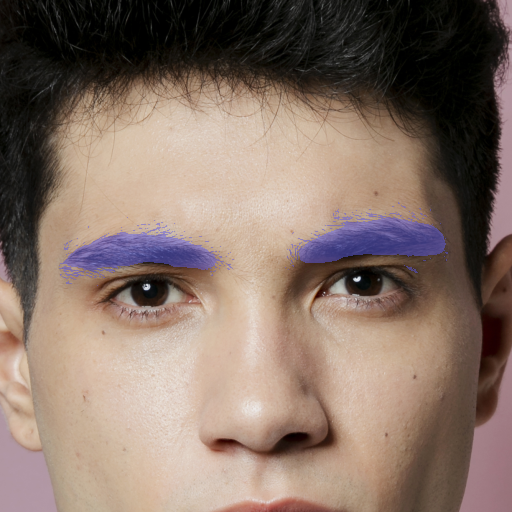

--- LaMa pass 1 ---


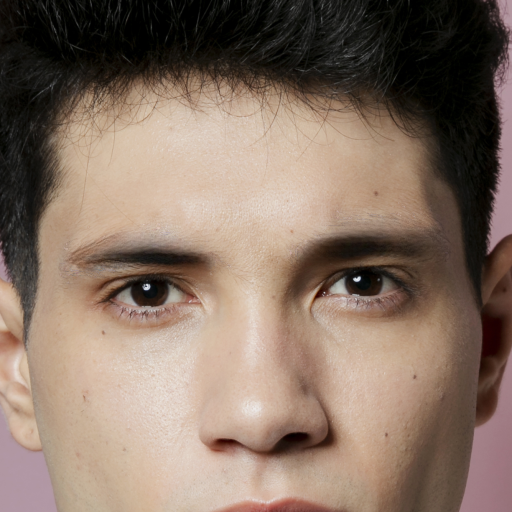

--- LaMa pass 2 ---


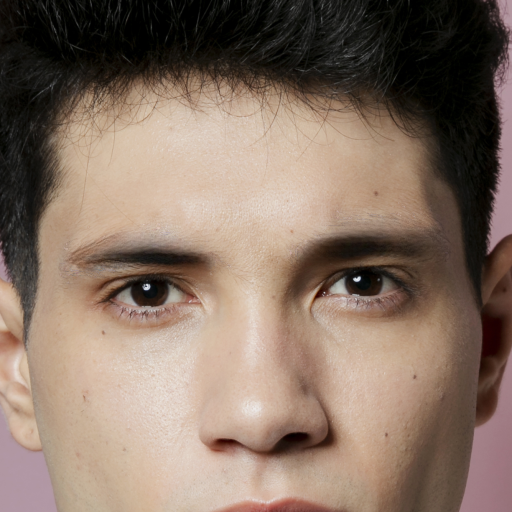

--- LaMa pass 3 ---


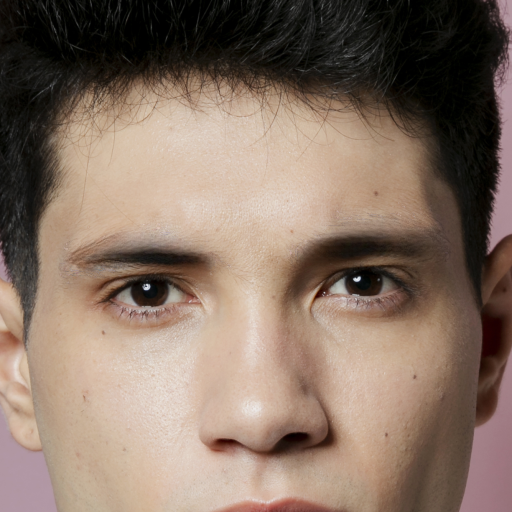

In [20]:
# ============================================================
# STEP 2. LaMa로 눈썹 지우기
# ============================================================
def step2_erase(S, lama, passes=3, dilate_px=None, eye_guard_px=None, use_bisenet=True):
    """[Phase2] BiSeNet 기반 마스크를 우선 사용하고, 실패 시 Phase1(랜드마크)로 자동 폴백한다.
    dilate_px / eye_guard_px를 None으로 두면 얼굴 크기(눈 사이 거리)에 비례해 자동 계산된다."""
    erase_mask, eye_guard, source = get_brow_mask_v2(
        S["image_512"], dilate_px=dilate_px, eye_guard_px=eye_guard_px,
        use_bisenet=use_bisenet,
    )

    if erase_mask is None or erase_mask.sum() == 0:
        print("[warn] 랜드마크 마스크도 실패 -> 크롭 단계 기본 마스크로 최종 폴백")
        erase_mask = S["mask_512_base"]
        eye_guard = None
        source = "fallback_base"

    print(f"[info] 지우기 마스크 소스: {source}, 픽셀 수: {int(np.count_nonzero(erase_mask))}")

    pil = Image.fromarray(cv2.cvtColor(S["image_512"], cv2.COLOR_BGR2RGB))
    mask_pil = Image.fromarray(erase_mask).convert("L")

    stages = []
    for _ in range(passes):
        pil = lama(pil, mask_pil)
        stages.append(cv2.cvtColor(np.array(pil), cv2.COLOR_RGB2BGR))

    S["erase_mask_512"] = erase_mask
    S["eye_guard_512"] = eye_guard      # [FIX] STEP3 feather 재클램프용으로 저장
    S["mask_source"] = source
    S["erased_512"] = stages[-1]
    S["erase_stages"] = stages          # 반복 횟수 튜닝용
    return S


S = step2_erase(S, lama, passes=3)   # BiSeNet 우선 시도, 실패 시 자동 폴백 [Phase2]
show(overlay(S["image_512"], S["erase_mask_512"]), f"LaMa 지우기 마스크 (source={S['mask_source']})")
for i, st in enumerate(S["erase_stages"], 1):
    show(st, f"LaMa pass {i}")


마스크: feathered, 최대값 251, 픽셀 25916


  0%|          | 0/28 [00:00<?, ?it/s]

--- 생성 마스크 ---


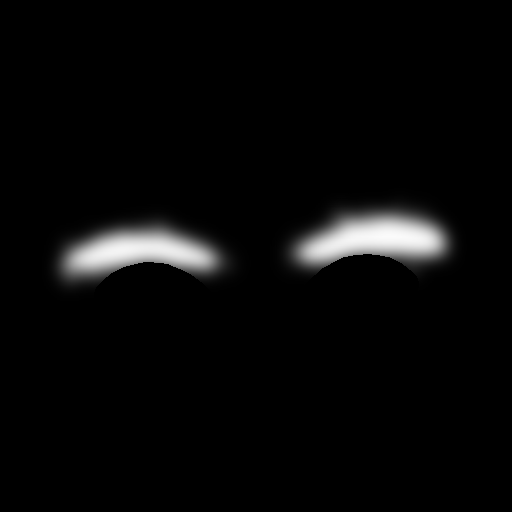

--- LaMa | 생성(원본) | 색보정 | 최종합성 | 원본 ---


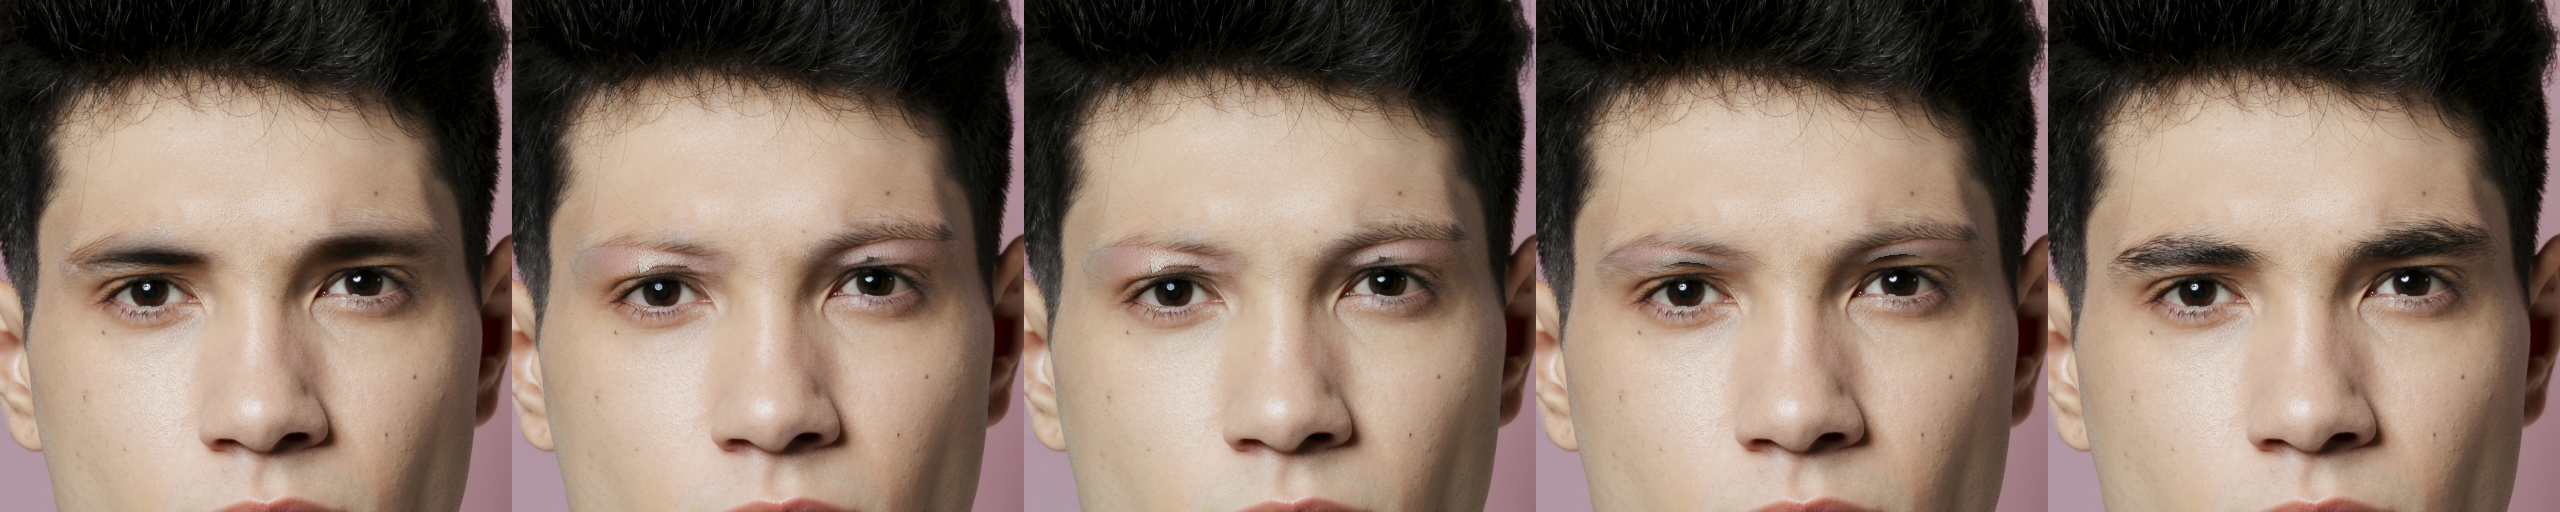

In [21]:
# ============================================================
# STEP 3. 눈썹 생성
# ============================================================
PROMPT_T = (
    "a photo of {celeb} style eyebrows on a face, "
    "highly detailed, realistic skin texture, natural skin pores, "
    "soft even diffused lighting"
)

# 네거티브 프롬프트
NEG = (
    "low quality, blurry, distorted, deformed, artifacts, "
    "cartoon, 3d render, painting, plastic skin, smooth skin, poreless, "
    "extra eyes, third eye, "
    "hard edges, seam, mismatched skin tone, "
    "eyeshadow, makeup, glitter, sparkle, pale pink, pastel"
)


def make_gen_mask(S, feather=25, dilate_px=0):
    """생성용 그라데이션 마스크. 중심은 255, 경계로 갈수록 0.

    [FIX] GaussianBlur는 경계를 사방으로 부드럽게 퍼뜨리는데, 이때 이미 0으로
    클램프해뒀던 눈 가드 영역까지 옅게 다시 살아날 수 있다 — 실제로 눈꺼풀에
    옅은 색이 번지는 원인이었다. 그래서 블러 이후에 eye_guard로 한 번 더 눌러준다.
    """
    m = S["erase_mask_512"].copy()          # LaMa에 쓴 것과 동일 영역
    if dilate_px > 0:
        m = dilate_mask(m, dilate_px)
    if feather > 0:
        k = feather * 2 + 1                 # 홀수 보장
        m = cv2.GaussianBlur(m, (k, k), 0)

    eye_guard = S.get("eye_guard_512")
    if eye_guard is not None:
        m[eye_guard > 0] = 0                # [FIX] 블러로 되살아난 눈 영역 재차단

    return m


def _color_transfer(src, ref, mask):
    """LAB 색공간에서, mask==0인(=배경/피부) 영역의 평균·표준편차 기준으로
    src(생성 결과)의 색 분포를 ref(원본/지운 이미지) 쪽으로 맞춘다.
    (원래 노트북에 있던 color_transfer와 동일 로직 — STEP3에서 항상 쓸 수 있도록 여기에 내장)"""
    bg_mask = (mask == 0)
    if not np.any(bg_mask):
        return src
    src_lab = cv2.cvtColor(src, cv2.COLOR_BGR2LAB).astype(np.float32)
    ref_lab = cv2.cvtColor(ref, cv2.COLOR_BGR2LAB).astype(np.float32)
    for i in range(3):
        src_channel = src_lab[:, :, i]
        ref_channel = ref_lab[:, :, i]
        mean_src, std_src = src_channel[bg_mask].mean(), src_channel[bg_mask].std()
        mean_ref, std_ref = ref_channel[bg_mask].mean(), ref_channel[bg_mask].std()
        if std_src > 1e-5:
            src_lab[:, :, i] = (src_channel - mean_src) * (std_ref / std_src) + mean_ref
        else:
            src_lab[:, :, i] = src_channel - mean_src + mean_ref
    return cv2.cvtColor(np.clip(src_lab, 0, 255).astype(np.uint8), cv2.COLOR_LAB2BGR)


def step3_generate(S, pipe, celeb, device,
                   seed=42, steps=40, guidance=7.0, strength=0.7,
                   lora_scale=1.15, feather=25, mask_mode="feathered"):
    """
    mask_mode:
      "feathered" — 눈썹 영역 그라데이션 (권장)
      "binary"    — 눈썹 영역 이진
      "white"     — 전체 흰색 (원본 방식, img2img)
    """
    if mask_mode == "white":
        gen_mask = np.full((512, 512), 255, np.uint8)
        eye_guard = S.get("eye_guard_512")
        if eye_guard is not None:
            gen_mask[eye_guard > 0] = 0     # [FIX] "white" 모드도 눈만은 지킨다
    elif mask_mode == "binary":
        gen_mask = S["erase_mask_512"]
    else:
        gen_mask = make_gen_mask(S, feather=feather)

    S["gen_mask_512"] = gen_mask
    print(f"마스크: {mask_mode}, 최대값 {gen_mask.max()}, "
          f"픽셀 {np.count_nonzero(gen_mask)}")

    out = pipe(
        prompt=PROMPT_T.format(celeb=celeb),
        negative_prompt=NEG,
        image=Image.fromarray(cv2.cvtColor(S["erased_512"], cv2.COLOR_BGR2RGB)),
        mask_image=Image.fromarray(gen_mask).convert("L"),
        num_inference_steps=steps,
        guidance_scale=guidance,
        strength=strength,
        generator=torch.Generator(device).manual_seed(seed),
        cross_attention_kwargs={"scale": lora_scale},
    ).images[0]

    S["generated_512"] = cv2.cvtColor(np.array(out), cv2.COLOR_RGB2BGR)

    # ------------------------------------------------------------------
    # [FIX] 피부가 연핑크로 뜨는 문제 대응.
    # SD Inpainting 파이프라인은 "마스크 바깥은 원본 그대로 고정"을 자동으로
    # 보장해주지 않는다 — 모델이 마스크 경계 근처 피부까지 같이 살짝 다시 그리면서
    # 색/조명을 자기 마음대로 해석해버리는 게 지금까지의 파스텔톤 원인이었다.
    # 그래서 생성 직후 두 단계를 추가한다:
    #   1) color_transfer — 생성 결과의 색 분포를 실제 피부(erased_512) 기준으로 보정
    #   2) blend          — 마스크 안쪽(눈썹)만 보정된 생성 결과를 쓰고,
    #                        마스크 바깥(피부)은 100% 원본으로 강제 고정
    # ------------------------------------------------------------------
    S["corrected_512"] = _color_transfer(S["generated_512"], S["erased_512"], gen_mask)
    S["final_512"] = blend(S["corrected_512"], S["image_512"], gen_mask)

    S["seed"] = seed
    return S


S = step3_generate(S, pipe, "고윤정", device, seed=42,
                   strength=0.7, feather=25, mask_mode="feathered")

show(S["gen_mask_512"], "생성 마스크")
show(np.hstack([S["erased_512"], S["generated_512"], S["corrected_512"], S["final_512"], S["image_512"]]),
     "LaMa | 생성(원본) | 색보정 | 최종합성 | 원본")


## [DEBUG] 생성 문제 원인 격리 — LoRA가 실제로 영향을 주고 있는지 확인

색보정(`color_transfer`)과 최종 합성(`blend`)을 넣어도 여전히 눈썹 자리가 연핑크로 나온다면,
이건 "색상 보정"으로 고칠 수 있는 문제가 아니라 **애초에 그 자리에 생성되는 내용 자체가 눈썹이 아니라는 뜻**입니다.

아래 셀은 같은 시드·같은 마스크로 3가지를 비교합니다.
1. **LoRA 켬** — 지금까지 쓰던 방식 그대로
2. **LoRA 끔** — 베이스 모델(epiCRealism)만으로 생성 (`disable_adapter()`로 LoRA 일시 비활성화)
3. **셀럽 이름 없이 일반 눈썹 프롬프트** — "자연스러운 진한 갈색 눈썹"이라는 평범한 프롬프트로 생성

**결과 해석법**
- 1번과 2번이 거의 똑같아 보인다 → LoRA가 실질적으로 결과에 영향을 못 주고 있다는 뜻. `cross_attention_kwargs`의 `scale`이
  `PeftModel`로 감싼 구조에는 제대로 안 먹히고 있을 가능성이 큽니다. → LoRA 로딩 방식 자체를 바꿔야 합니다.
- 1번과 2번이 확실히 다르다(LoRA가 뭔가 영향을 주고 있다) → LoRA는 작동은 하는데, 학습 자체가 "눈썹"이 아니라
  다른 걸(예: 화장/조명) 학습했을 가능성 → 체크포인트나 학습 데이터를 다시 봐야 합니다.
- 3번(일반 프롬프트)이 1번보다 훨씬 자연스럽다 → 지금 프롬프트 형식이 LoRA 학습 때 쓴 프롬프트 형식과 안 맞을 가능성.


  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

--- 1.LoRA 켬 | 2.LoRA 끔(베이스만) | 3.일반 눈썹 프롬프트 | 원본 ---


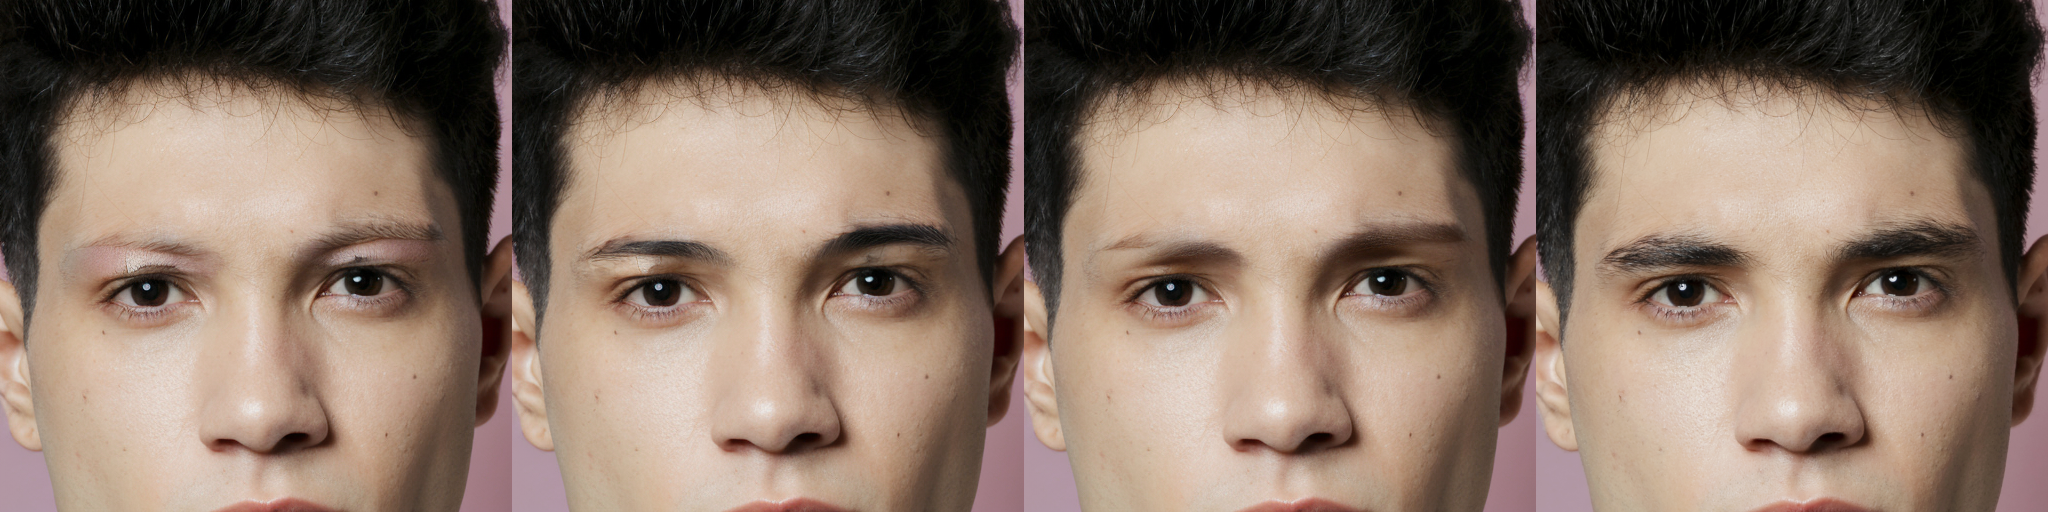

In [22]:
# ============================================================
# STEP 3-DEBUG. 생성 문제 원인 격리 테스트
# ============================================================
def step3_debug_ablation(S, pipe, celeb, device, seed=42):
    gen_mask = S["gen_mask_512"]
    base_kwargs = dict(
        negative_prompt=NEG,
        image=Image.fromarray(cv2.cvtColor(S["erased_512"], cv2.COLOR_BGR2RGB)),
        mask_image=Image.fromarray(gen_mask).convert("L"),
        num_inference_steps=40,
        guidance_scale=7.0,
        strength=0.7,
    )

    results = {}

    # 1) LoRA 켠 상태 (지금까지와 동일)
    out = pipe(prompt=PROMPT_T.format(celeb=celeb),
               generator=torch.Generator(device).manual_seed(seed),
               cross_attention_kwargs={"scale": 1.15}, **base_kwargs).images[0]
    results["lora_on"] = cv2.cvtColor(np.array(out), cv2.COLOR_RGB2BGR)

    # 2) LoRA를 완전히 끈 상태 (베이스 모델만) — PEFT의 disable_adapter 컨텍스트 매니저 사용
    with pipe.unet.disable_adapter(), pipe.text_encoder.disable_adapter():
        out = pipe(prompt=PROMPT_T.format(celeb=celeb),
                   generator=torch.Generator(device).manual_seed(seed), **base_kwargs).images[0]
    results["lora_off"] = cv2.cvtColor(np.array(out), cv2.COLOR_RGB2BGR)

    # 3) LoRA 켠 상태 + 셀럽 이름 없이 일반적인 눈썹 프롬프트
    out = pipe(prompt="a photo of natural thick dark brown eyebrows on a face, "
                      "detailed eyebrow hair strands, realistic skin",
               generator=torch.Generator(device).manual_seed(seed),
               cross_attention_kwargs={"scale": 1.15}, **base_kwargs).images[0]
    results["generic_prompt"] = cv2.cvtColor(np.array(out), cv2.COLOR_RGB2BGR)

    show(np.hstack([results["lora_on"], results["lora_off"],
                    results["generic_prompt"], S["image_512"]]),
         "1.LoRA 켬 | 2.LoRA 끔(베이스만) | 3.일반 눈썹 프롬프트 | 원본")
    return results


debug_results = step3_debug_ablation(S, pipe, "고윤정", device)


## [NEW] 여러 사진 / 여러 셀럽 일괄 테스트 (배치 실행)

`TEST_IMAGE_PATH` 하나로 사진 한 장씩 테스트하는 대신, 아래 셀은 **사진 여러 장 × 셀럽 여러 명**을 한 번에 돌려서
결과를 비교할 수 있게 해줍니다.

사용법은 딱 두 가지 리스트만 채우면 됩니다.
- `BATCH_IMAGE_NAMES` — 미리 Google Drive의 `eyebrows` 폴더에 올려둔 사진 파일명들
- `BATCH_CELEBS` — 테스트해볼 셀럽 이름들 (LoRA가 지원하는 이름이어야 합니다)

리스트에 있는 조합을 전부 돌면서, 결과 이미지를 화면에 보여주고 `output_img/outputs/` 폴더에도 저장합니다.
어느 사진이 BiSeNet 마스크를 썼는지 랜드마크 마스크로 폴백했는지(`mask_source`)도 같이 확인할 수 있습니다.



===== test.jpg x 고윤정 =====
[info] 지우기 마스크 소스: bisenet, 픽셀 수: 9175
마스크: feathered, 최대값 251, 픽셀 25916


  0%|          | 0/28 [00:00<?, ?it/s]

--- test.jpg | 고윤정 | mask_source=bisenet | LaMa-생성-최종합성-원본 ---


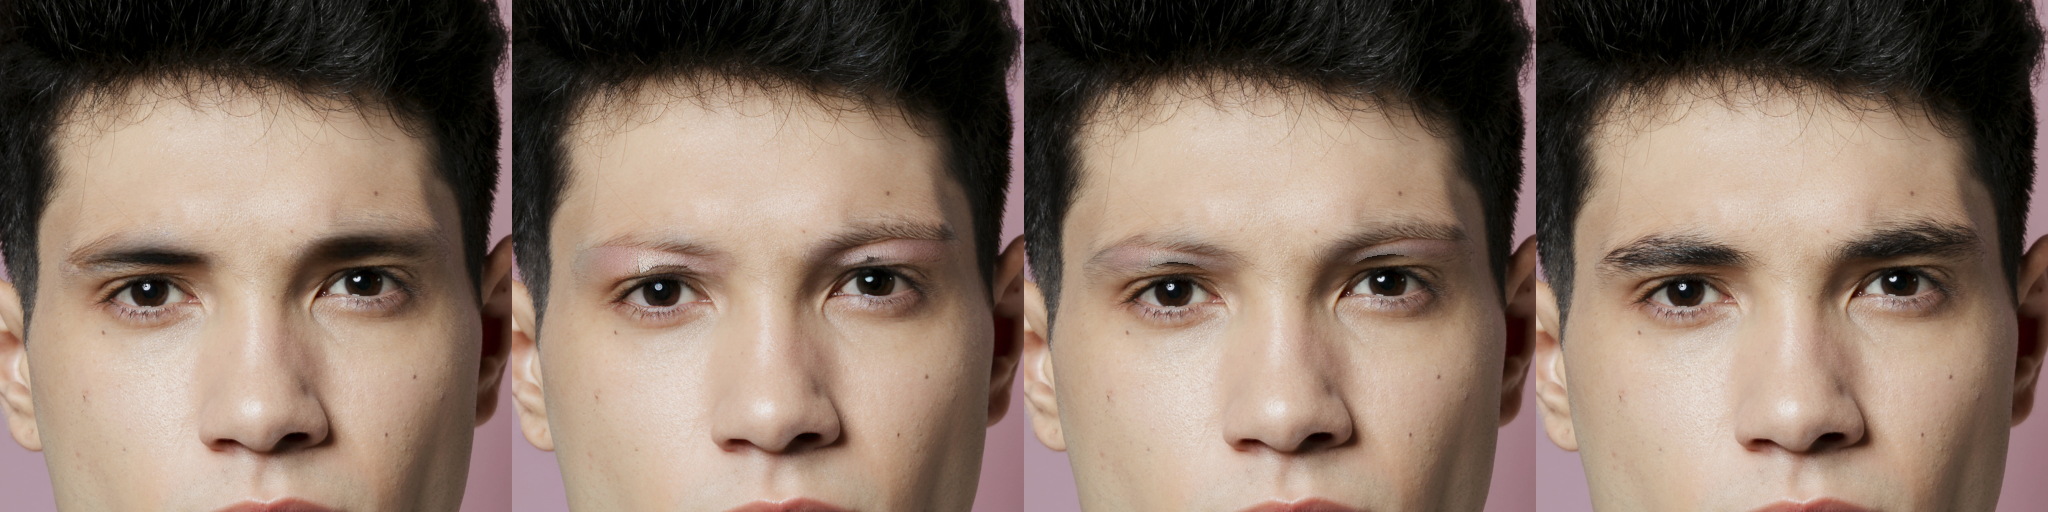

[saved] /content/drive/MyDrive/eyebrows/output_img/outputs/test_고윤정_20260818_053516.png

===== test2.jpg x 고윤정 =====
[info] 지우기 마스크 소스: bisenet, 픽셀 수: 3483
마스크: feathered, 최대값 219, 픽셀 15087


  0%|          | 0/28 [00:00<?, ?it/s]

--- test2.jpg | 고윤정 | mask_source=bisenet | LaMa-생성-최종합성-원본 ---


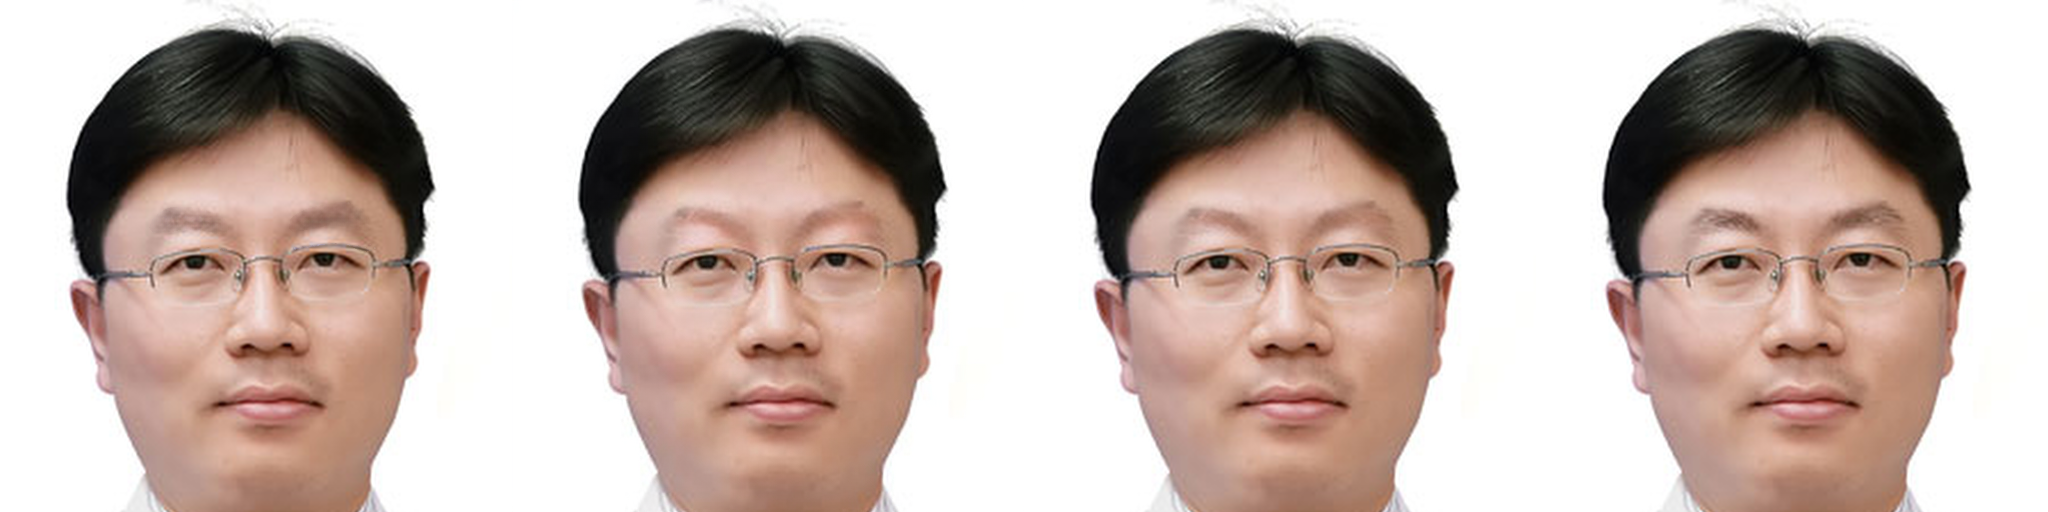

[saved] /content/drive/MyDrive/eyebrows/output_img/outputs/test2_고윤정_20260818_053525.png

총 2건 처리 완료
{'image': 'test.jpg', 'celeb': '고윤정', 'mask_source': 'bisenet', 'output_path': '/content/drive/MyDrive/eyebrows/output_img/outputs/test_고윤정_20260818_053516.png'}
{'image': 'test2.jpg', 'celeb': '고윤정', 'mask_source': 'bisenet', 'output_path': '/content/drive/MyDrive/eyebrows/output_img/outputs/test2_고윤정_20260818_053525.png'}


In [23]:
# ============================================================
# STEP 4. 여러 사진 / 여러 셀럽 일괄 테스트 (배치 실행)
# ============================================================
import os, cv2, datetime
import numpy as np

# [설정] 테스트하고 싶은 사진 파일명들을 여기에 적으세요.
# 사진은 미리 Google Drive의 eyebrows 폴더(ROOT_PATH)에 올려둬야 합니다.
BATCH_IMAGE_NAMES = [
    TEST_IMAGE_NAME,   # 기본으로 위에서 설정한 사진 하나는 항상 포함
    "test2.jpg",
    # "actor3.jpg",
]

# [설정] 비교해보고 싶은 셀럽 이름들
BATCH_CELEBS = [
    "고윤정",
    # "신세경",
    # "홍수주",
]

OUT_DIR = os.path.join(ROOT_PATH, "output_img", "outputs")
os.makedirs(OUT_DIR, exist_ok=True)

batch_results = []

for image_name in BATCH_IMAGE_NAMES:
    image_path = os.path.join(ROOT_PATH, image_name)
    if not os.path.isfile(image_path):
        print(f"[skip] 파일 없음: {image_path}")
        continue

    for celeb in BATCH_CELEBS:
        print(f"\n===== {image_name} x {celeb} =====")
        try:
            S = step1_prepare(image_path)
            S = step2_erase(S, lama, passes=3)          # BiSeNet 우선 시도, 실패 시 자동 폴백
            S = step3_generate(S, pipe, celeb, device,
                                seed=42, strength=0.7, feather=25,
                                mask_mode="feathered")
        except Exception as e:
            print(f"[error] {image_name} x {celeb}: {e}")
            continue

        # 결과 미리보기: LaMa 지우기 | 생성 결과 | 원본
        show(np.hstack([S["erased_512"], S["generated_512"], S["final_512"], S["image_512"]]),
             f"{image_name} | {celeb} | mask_source={S.get('mask_source')} | LaMa-생성-최종합성-원본")

        # 결과 파일로 저장 (사진명_셀럽명_타임스탬프.png)
        stem = os.path.splitext(image_name)[0]
        ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        out_path = os.path.join(OUT_DIR, f"{stem}_{celeb}_{ts}.png")
        cv2.imwrite(out_path, S["final_512"])   # [FIX] 색보정+피부 고정된 최종 합성본 저장
        print(f"[saved] {out_path}")

        batch_results.append({
            "image": image_name,
            "celeb": celeb,
            "mask_source": S.get("mask_source"),
            "output_path": out_path,
        })

print(f"\n총 {len(batch_results)}건 처리 완료")
for r in batch_results:
    print(r)
